In [1]:
import string
import numpy as np
from PIL import Image
import os
from pickle import dump, load
import numpy as np


from keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from tensorflow.keras.layers import add
from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout
from transformers import ViTFeatureExtractor, ViTModel
import torch

# small library for seeing the progress of loops.
from tqdm.notebook import tqdm
# tqdm().pandas()

In [2]:
## run 
# Loading a text file into memory
def load_doc(filename):
    # Opening the file as read only
    file = open(filename, 'r')
    text = file.read()
    file.close()
    return text

# get all imgs with their captions
def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions ={}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [ caption ]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

#Data cleaning- lower casing, removing puntuations and words containing numbers
def cleaning_text(captions):
    table = str.maketrans('','',string.punctuation)
    for img,caps in captions.items():
        for i,img_caption in enumerate(caps):

            img_caption.replace("-"," ")
            desc = img_caption.split()

            #converts to lowercase
            desc = [word.lower() for word in desc]
            #remove punctuation from each token
            desc = [word.translate(table) for word in desc]
            #remove hanging 's and a 
            desc = [word for word in desc if(len(word)>1)]
            #remove tokens with numbers in them
            desc = [word for word in desc if(word.isalpha())]
            #convert back to string

            img_caption = ' '.join(desc)
            captions[img][i]= img_caption
    return captions

def text_vocabulary(descriptions):
    # build vocabulary of all unique words
    vocab = set()

    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]

    return vocab

#All descriptions in one file 
def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc )
    data = "\n".join(lines)
    file = open(filename,"w")
    file.write(data)
    file.close()


In [3]:
## run 

# Set these path according to project folder in you system
# dataset_text = "D:\dataflair projects\Project - Image Caption Generator\Flickr_8k_text"
# dataset_images = "D:\dataflair projects\Project - Image Caption Generator\Flicker8k_Dataset"
dataset_text = "dataset/Flickr8k_text"
dataset_images = "dataset/Flicker8k_Dataset"

#we prepare our text data
filename = dataset_text + "/" + "Flickr8k.token.txt"
#loading the file that contains all data
#mapping them into descriptions dictionary img to 5 captions
descriptions = all_img_captions(filename)
print("Length of descriptions =" ,len(descriptions))

#cleaning the descriptions
clean_descriptions = cleaning_text(descriptions)

#building vocabulary 
vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary = ", len(vocabulary))

#saving each description to file 
save_descriptions(clean_descriptions, "descriptions.txt")

Length of descriptions = 8092
Length of vocabulary =  8763


In [4]:
## run 


feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

def extract_features_vit(directory):
    features = {}
    for img_name in tqdm(os.listdir(directory)):
        path = os.path.join(directory, img_name)
        image = Image.open(path).convert("RGB")

        # Preprocess image
        inputs = feature_extractor(images=image, return_tensors="pt")

        # Extract features with ViT
        with torch.no_grad():
            outputs = vit_model(**inputs)
        
        # Mean pool all patch embeddings (excluding CLS token if you want)
        pooled_features = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        features[img_name] = pooled_features  # Shape: (768,)
    
    return features


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [5]:
## dont run everytime
#768 feature vector for ViT
features = extract_features_vit(dataset_images)
dump(features, open("features.p","wb"))

  0%|          | 0/8091 [00:00<?, ?it/s]

In [6]:
#load the data 
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos


def load_clean_descriptions(filename, photos): 
    #loading clean_descriptions
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):

        words = line.split()
        if len(words)<1 :
            continue

        image, image_caption = words[0], words[1:]

        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)

    return descriptions


def load_features(photos):
    #loading all features
    all_features = load(open("features.p","rb"))
    #selecting only needed features
    features = {k:all_features[k] for k in photos}
    return features



filename = dataset_text + "/" + "Flickr_8k.trainImages.txt"

#train = loading_data(filename)
train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)

In [7]:
#converting dictionary to clean list of descriptions
def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

#creating tokenizer class 
#this will vectorise text corpus
#each integer will represent token in dictionary

from keras.preprocessing.text import Tokenizer

def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer


In [8]:

# give each word an index, and store that into tokenizer.p pickle file
tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
vocab_size

7577

In [9]:
#calculate maximum length of descriptions
def max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)
    
max_length = max_length(descriptions)
max_length

32

### Data Generator

In [10]:


from keras.utils import to_categorical
import numpy as np

# Load extracted ViT features
features = load(open("features.p", "rb"))

# Create sequences for training
def create_sequences(tokenizer, max_length, descriptions, photos, vocab_size):
    X1, X2, y = [], [], []

    for key, desc_list in descriptions.items():
        if key not in photos:
            continue
        for desc in desc_list:
            seq = tokenizer.texts_to_sequences([desc])[0]
            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                X1.append(photos[key])
                X2.append(in_seq)
                y.append(out_seq)
    
    return np.array(X1), np.array(X2), np.array(y)

### model 



In [11]:
def define_model(vocab_size, max_length):
    inputs1 = Input(shape=(768,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

model = define_model(vocab_size, max_length)
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 32)]                 0         []                            
                                                                                                  
 input_1 (InputLayer)        [(None, 768)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 32, 256)              1939712   ['input_2[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 768)                  0         ['input_1[0][0]']             
                                                                                              

### Training

In [12]:
print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)

from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# Prepare data
X1train, X2train, ytrain = create_sequences(tokenizer, max_length, train_descriptions, train_features, vocab_size)

# Train the model
model.fit([X1train, X2train], ytrain, epochs=40, batch_size=64, callbacks=[early_stop], verbose=1)

# Save the trained model
model.save("vit_caption_model.h5")





Dataset:  6000
Descriptions: train= 6000
Photos: train= 6000
Vocabulary Size: 7577
Description Length:  32
Epoch 1/40
4788/4788 [==============================] - 335s 70ms/step - loss: 4.3061
Epoch 2/40
4788/4788 [==============================] - 319s 67ms/step - loss: 3.4805
Epoch 3/40
4788/4788 [==============================] - 327s 68ms/step - loss: 3.1842
Epoch 4/40
4788/4788 [==============================] - 324s 68ms/step - loss: 3.0040
Epoch 5/40
4788/4788 [==============================] - 323s 67ms/step - loss: 2.8779
Epoch 6/40
4788/4788 [==============================] - 335s 70ms/step - loss: 2.7865
Epoch 7/40
4788/4788 [==============================] - 334s 70ms/step - loss: 2.7131
Epoch 8/40
4788/4788 [==============================] - 337s 70ms/step - loss: 2.6589
Epoch 9/40
4788/4788 [==============================] - 332s 69ms/step - loss: 2.6138
Epoch 10/40
4788/4788 [==============================] - 317s 66ms/step - loss: 2.5742
Epoch 11/40
4788/4788 [=========

/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [13]:
# import math
# for epoch in range(1, 3):
#     epoch_start_time = time.time()
#     loss = train()
#     print('-' * 89)
#     print('| end of epoch {:3d} | time: {:5.2f}s | Training loss {:5.2f} | '
#           .format(epoch, (time.time() - epoch_start_time),
#                                      loss))

### Testing 

In [14]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import argparse


def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_caption_from_features(model, tokenizer, photo, max_length):
    in_text = 'start'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = word_for_id(yhat, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'end':
            break
    return in_text.replace('start', '').replace('end', '').strip()



from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

def evaluate_model(model, descriptions, photos, tokenizer, max_length):
    smooth = SmoothingFunction().method4
    actual, predicted = [], []
    scores = []

    for key, desc_list in tqdm(descriptions.items()):
        if key not in photos:
            continue
        yhat = generate_caption_from_features(model, tokenizer, photos[key].reshape(1, 768), max_length)
        references = [d.split() for d in desc_list]
        candidate = yhat.split()
        actual.append(references)
        predicted.append(candidate)

        bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
        meteor = meteor_score(references, candidate)

        scores.append((key, yhat, bleu1, bleu2, bleu3, bleu4, meteor))

    return scores


test_imgs = load_photos(dataset_text + "/Flickr_8k.testImages.txt")
test_descriptions = load_clean_descriptions("descriptions.txt", test_imgs)
test_features = load_features(test_imgs)

# Load everything
model = load_model("vit_caption_model.h5")
# features = load(open("features.p", "rb"))
# # descriptions = load_descriptions("Flickr8k_text/Flickr8k.token.txt")
# descriptions = clean_descriptions

# Evaluate
# results = evaluate_model(model, descriptions, features, tokenizer, max_length)

results = evaluate_model(model, test_descriptions, test_features, tokenizer, max_length)


  0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
def display_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Average BLEU-1: 0.4475
Average BLEU-2: 0.2691
Average BLEU-3: 0.1725
Average BLEU-4: 0.1130
Average METEOR: 0.2698


 Top 5 Captions by BLEU-4:

Image: 317488612_70ac35493b.jpg
Caption: dog is running through the snow
BLEU-4: 0.8465


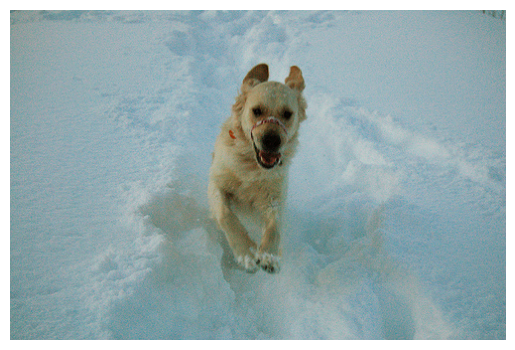

Image: 3363750526_efcedc47a9.jpg
Caption: dog is running on the sand
BLEU-4: 0.8465


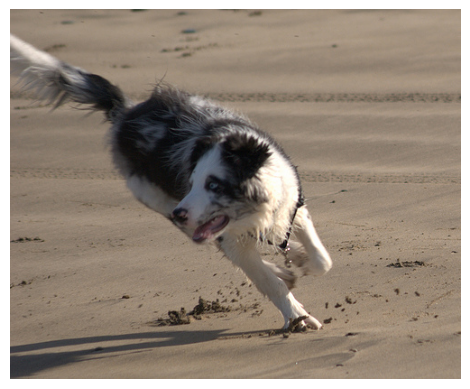

Image: 3162045919_c2decbb69b.jpg
Caption: man in wetsuit is surfing
BLEU-4: 0.8187


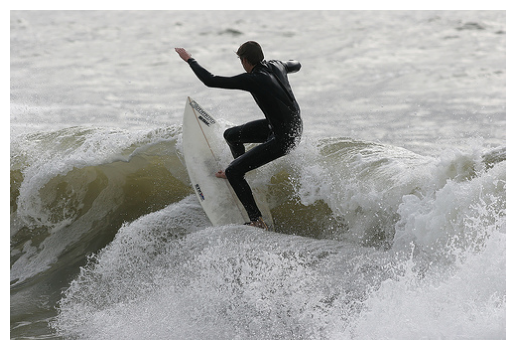

Image: 115684808_cb01227802.jpg
Caption: two people are standing in the snow
BLEU-4: 0.8091


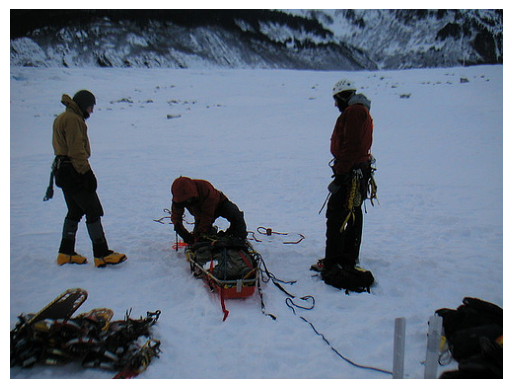

Image: 1467533293_a2656cc000.jpg
Caption: two girls are playing on playground
BLEU-4: 0.7649


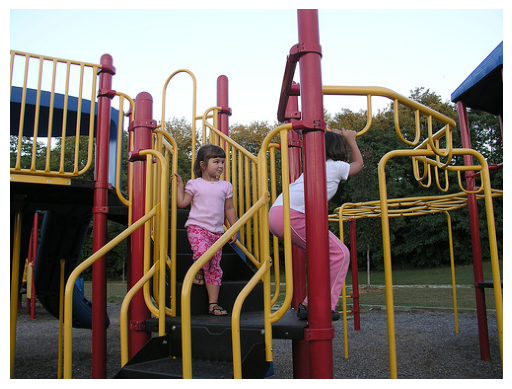


 Bottom 5 Captions by BLEU-4:

Image: 2505988632_9541f15583.jpg
Caption: two children in bathing suits are running through school place
BLEU-4: 0.0000


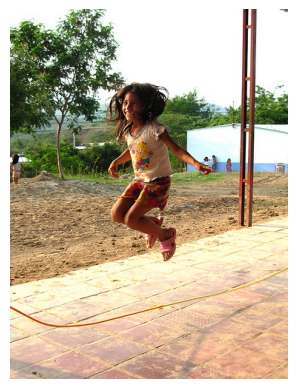

Image: 3044500219_778f9f2b71.jpg
Caption: two brunettes with tattoos hug each other
BLEU-4: 0.0000


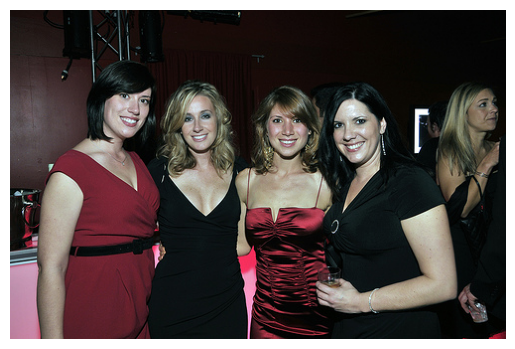

Image: 3258874419_23fec1bdc1.jpg
Caption: three dogs racing around track
BLEU-4: 0.0000


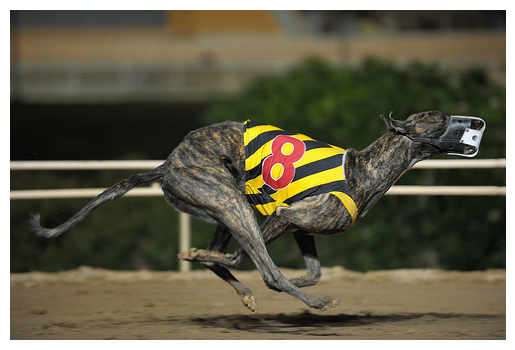

Image: 327415627_6313d32a64.jpg
Caption: dog is jumping over wire fence
BLEU-4: 0.0000


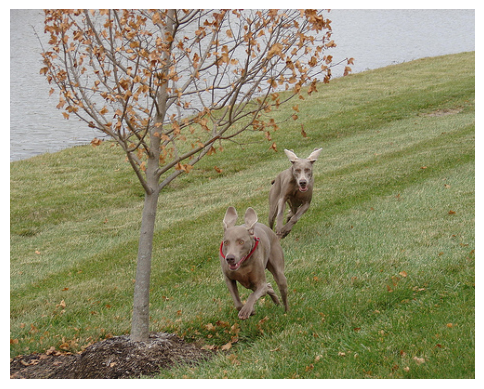

Image: 3425835357_204e620a66.jpg
Caption: two boys are walking through focus
BLEU-4: 0.0000


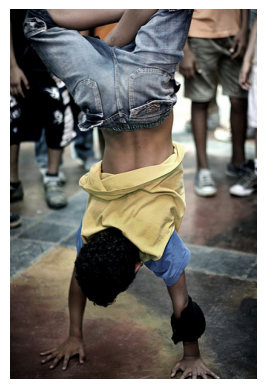

In [22]:
def summarize_scores(results):
    bleu1_scores = [r[2] for r in results]
    bleu2_scores = [r[3] for r in results]
    bleu3_scores = [r[4] for r in results]
    bleu4_scores = [r[5] for r in results]
    meteor_scores = [r[6] for r in results]

    print("Average BLEU-1: {:.4f}".format(np.mean(bleu1_scores)))
    print("Average BLEU-2: {:.4f}".format(np.mean(bleu2_scores)))
    print("Average BLEU-3: {:.4f}".format(np.mean(bleu3_scores)))
    print("Average BLEU-4: {:.4f}".format(np.mean(bleu4_scores)))
    print("Average METEOR: {:.4f}".format(np.mean(meteor_scores)))



summarize_scores(results)
print("\n")

image_dir = "dataset/Flicker8k_Dataset/"
# Top 5 by BLEU-4
sorted_by_bleu4 = sorted(results, key=lambda x: x[5], reverse=True)
print(" Top 5 Captions by BLEU-4:\n")
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))

# # Bottom 5 by METEOR

# print("\n Bottom 5 Captions by METEOR:\n")
# sorted_by_meteor = sorted(results, key=lambda x: x[6])
# for r in sorted_by_meteor[:5]:
#     print(f"Image: {r[0]}")
#     print(f"Caption: {r[1]}")
#     print(f"METEOR: {r[6]:.4f}")
#     display_image(os.path.join(image_dir, r[0]))


## BOTTOM 5 BY BLEU

# Bottom 5 by METEOR

print("\n Bottom 5 Captions by BLEU-4:\n")
sorted_by_bleu4 = sorted(results, key=lambda x: x[5])
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))









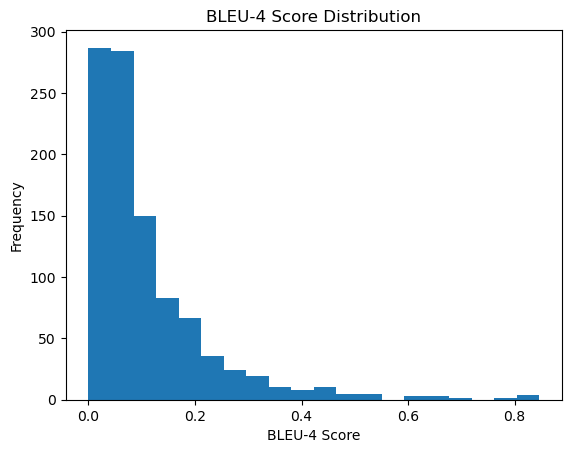

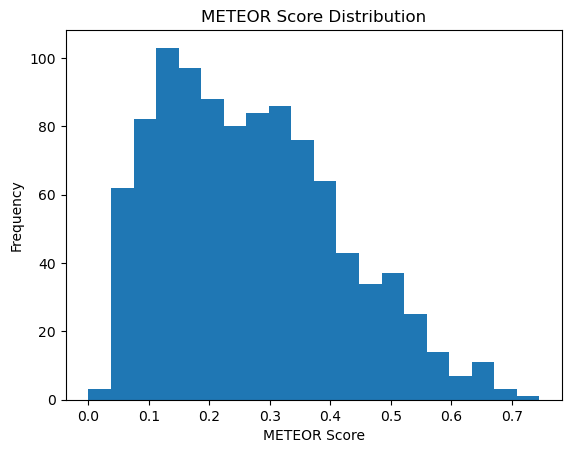

In [17]:
import matplotlib.pyplot as plt

bleu4 = [r[5] for r in results]
meteor = [r[6] for r in results]

plt.hist(bleu4, bins=20)
plt.title("BLEU-4 Score Distribution")
plt.xlabel("BLEU-4 Score")
plt.ylabel("Frequency")
plt.show()

plt.hist(meteor, bins=20)
plt.title("METEOR Score Distribution")
plt.xlabel("METEOR Score")
plt.ylabel("Frequency")
plt.show()


In [18]:
def evaluate_single_image(model, tokenizer, image_path, descriptions_dict, vit_model, feature_extractor, max_length):
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from nltk.translate.meteor_score import meteor_score
    from PIL import Image

    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt")

    # Extract ViT features
    with torch.no_grad():
        outputs = vit_model(**inputs)
    photo = outputs.last_hidden_state.mean(dim=1).squeeze().numpy().reshape(1, 768)

    # Generate caption
    caption = generate_caption_from_features(model, tokenizer, photo, max_length)
    print(f"Generated Caption: {caption}")

    # Get the image ID (e.g., "123456.jpg")
    image_id = os.path.basename(image_path)

    # Get reference captions
    if image_id not in descriptions_dict:
        print("No reference captions found for this image.")
        return

    references = [d.split() for d in descriptions_dict[image_id]]
    candidate = caption.split()

    # Evaluation
    smooth = SmoothingFunction().method4
    bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
    bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
    bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
    bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    meteor = meteor_score(references, candidate)

    print(f"BLEU-1: {bleu1:.4f}, BLEU-2: {bleu2:.4f}, BLEU-3: {bleu3:.4f}, BLEU-4: {bleu4:.4f}")
    print(f"METEOR: {meteor:.4f}")


Generated Caption: man in red jacket is standing on the grass with his mouth open
No reference captions found for this image.


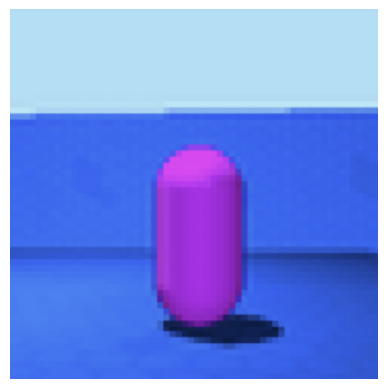

In [19]:
# image_path = "dataset/Flicker8k_Dataset/2513260012_03d33305cf.jpg"  # Change to your image
image_path = "dataset/pill.png" 
# image_path = "dataset/Flicker8k_Dataset/3738685861_8dfff28760.jpg" 
# image_path = "dataset/Flicker8k_Dataset/3759230208_1c2a492b12.jpg" 
# image_path = "dataset/Flicker8k_Dataset/3767841911_6678052eb6.jpg" 
# image_path = "dataset/Flicker8k_Dataset/3726700898_c50494b8bd.jpg" 
# image_path = "dataset/Flicker8k_Dataset/3726019124_f302b3d48a.jpg" 

evaluate_single_image(
    model=model,
    tokenizer=tokenizer,
    image_path=image_path,
    descriptions_dict=clean_descriptions,
    vit_model=vit_model,
    feature_extractor=feature_extractor,
    max_length=max_length
)

# Display image
# img = Image.open(image_path)
# plt.imshow(img)
# plt.axis("off")
# plt.show()
display_image(image_path)


## Testing gradio

In [20]:
# Re-import everything after kernel reset
import sqlite3
import numpy as np
import torch
import pickle
from PIL import Image
from io import BytesIO
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import ViTFeatureExtractor, ViTModel

# Load tokenizer, model, feature extractor, and ViT
tokenizer = pickle.load(open("tokenizer.p", "rb"))
max_length = 32
caption_model = load_model('vit_caption_model.h5')
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

# SQLite DB
DB_FILE = "images.db"

# Initialize DB
def init_db():
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS images (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                image BLOB NOT NULL,
                caption TEXT NOT NULL,
                embedding BLOB NOT NULL
            )
        ''')
        conn.commit()

init_db()

# Helper: decode predicted word
def word_for_id(integer, tokenizer):
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

# Caption generation from features
def generate_caption_from_features(model, tokenizer, photo, max_length):
    in_text = 'start'
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = word_for_id(yhat, tokenizer)
        if word is None or word == 'end':
            break
        in_text += ' ' + word
    return in_text.replace("start", "").strip()

# Full image captioning + save
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt")
    with torch.no_grad():
        vit_features = vit_model(**inputs).last_hidden_state.mean(dim=1)
    photo = vit_features.reshape(1, 768).numpy()
    caption = generate_caption_from_features(caption_model, tokenizer, photo, max_length)
    saveImageDesc(image_path, caption, photo.squeeze())
    return caption

# Save image + caption + embedding
def saveImageDesc(img_path, caption, embedding):
    img = Image.open(img_path)
    img_bytes = BytesIO()
    img.save(img_bytes, format="PNG")
    img_data = img_bytes.getvalue()
    emb_blob = pickle.dumps(embedding)

    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("INSERT INTO images (image, caption, embedding) VALUES (?, ?, ?)", 
                       (img_data, caption, emb_blob))
        conn.commit()

# Text-to-image (caption-based keyword match)
def search_images(keyword):
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image FROM images WHERE caption LIKE ?", ('%' + keyword + '%',))
        rows = cursor.fetchall()
    images = [Image.open(BytesIO(row[0])) for row in rows] if rows else []
    return gr.Gallery(images, columns=2)

# Updated image_to_image_search using CLS token and normalized vectors

def image_to_image_search(query_path, threshold=0.80):
    query_img = Image.open(query_path).convert("RGB")
    inputs = feature_extractor(images=query_img, return_tensors="pt")
    with torch.no_grad():
        query_embedding = vit_model(**inputs).last_hidden_state[:, 0, :].squeeze().numpy()
        query_embedding /= np.linalg.norm(query_embedding)

    results = []
    with sqlite3.connect(DB_FILE) as conn:
        cursor = conn.cursor()
        cursor.execute("SELECT image, embedding FROM images")
        for row in cursor.fetchall():
            img_data, emb_blob = row
            stored_embedding = pickle.loads(emb_blob)
            stored_embedding /= np.linalg.norm(stored_embedding)
            sim = cosine_similarity([query_embedding], [stored_embedding])[0][0]

            if sim >= threshold:
                results.append((sim, img_data))

    results.sort(reverse=True, key=lambda x: x[0])
    top_images = [Image.open(BytesIO(r[1])) for r in results[:5]]
    return gr.Gallery(top_images, columns=2)



# Gradio Interfaces
caption_iface = gr.Interface(
    fn=generate_caption,
    inputs=gr.Image(type="filepath"),
    outputs="text",
    title="Image Caption Generator",
    description="Upload an image to generate a caption and store it locally."
)

search_text_iface = gr.Interface(
    fn=search_images,
    inputs="text",
    outputs=gr.Gallery(),
    title="Search Images by Text",
    description="Search images based on their generated captions."
)

search_image_iface = gr.Interface(
    fn=image_to_image_search,
    inputs=[
        gr.Image(type="filepath", label="Query Image"),
        gr.Slider(0.0, 1.0, step=0.01, value=0.80, label="Similarity Threshold")
    ],
    outputs=gr.Gallery(),
    title="Search Images by Image",
    description="Upload an image and filter similar results by cosine similarity."
)


# Launch all interfaces
gr.TabbedInterface(
    [caption_iface, search_text_iface, search_image_iface],
    ["Generate Caption", "Search by Text", "Search by Image"]
).launch()


/Users/abhinandanvijan/anaconda3/lib/python3.11/site-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


IMPORTANT: You are using gradio version 4.36.1, however version 4.44.1 is available, please upgrade.
--------


In [21]:
# import gradio as gr
# import sqlite3
# import numpy as np
# from tensorflow.keras.models import load_model
# from PIL import Image
# import io
# import pickle
# from tensorflow.keras.applications.xception import Xception


# import pickle
# tokenizer = pickle.load(open("tokenizer.p", "rb"))
# max_length = 32  # or load this from config if saved


# # Load trained image captioning model
# # model = load_model('models/model_8.h5')
# caption_model = load_model('vit_caption_model.h5')

# # SQLite database file
# DB_FILE = "images.db"

# # Create table if not exists
# def init_db():
#     with sqlite3.connect(DB_FILE) as conn:
#         cursor = conn.cursor()
#         cursor.execute('''
#             CREATE TABLE IF NOT EXISTS images (
#                 id INTEGER PRIMARY KEY AUTOINCREMENT,
#                 image BLOB NOT NULL,
#                 caption TEXT NOT NULL
#             )
#         ''')
#         conn.commit()

# init_db()

# import gradio as gr
# from PIL import Image
# import torch

# def generate_caption(image_path):
#     image = Image.open(image_path).convert("RGB")
#     inputs = feature_extractor(images=image, return_tensors="pt")
#     with torch.no_grad():
#         vit_features = vit_model(**inputs).last_hidden_state.mean(dim=1)
#     photo = vit_features.reshape(1, 768).numpy()

#     # Call the reusable function
#     caption = generate_caption_from_features(caption_model, tokenizer, photo, max_length)
#     saveImageDesc(image_path, caption)
#     return caption



# def saveImageDesc(img_path, caption):
#     img = Image.open(img_path)

#     # Convert image to bytes for storing in SQLite
#     img_bytes = io.BytesIO()
#     img.save(img_bytes, format="PNG")
#     img_data = img_bytes.getvalue()

#     # Store in SQLite
#     with sqlite3.connect(DB_FILE) as conn:
#         cursor = conn.cursor()
#         cursor.execute("INSERT INTO images (image, caption) VALUES (?, ?)", (img_data, caption))
#         cursor.execute('''
#             CREATE TABLE IF NOT EXISTS images (
#                 id INTEGER PRIMARY KEY AUTOINCREMENT,
#                 image BLOB NOT NULL,
#                 caption TEXT NOT NULL,
#                 embedding BLOB NOT NULL
#             )
#         ''')
#         conn.commit()
#         print(f"{img_path} added to database.")

# # **Updated Search Function for Multiple Images**
# def search_images(keyword):
#     with sqlite3.connect(DB_FILE) as conn:
#         cursor = conn.cursor()
#         cursor.execute("SELECT image FROM images WHERE caption LIKE ?", ('%' + keyword + '%',))
#         rows = cursor.fetchall()  # Fetch all matching rows

#     if rows:
#         images = [Image.open(io.BytesIO(row[0])) for row in rows]  # Convert binary data to images
#         # Return the list of images as a Gradio gallery, set columns to 2 directly
#         return gr.Gallery(images, columns=2)  # Display images in 2 columns
#     else:
#         return gr.Gallery([])  # Return a message if no image is found

# # Create Gradio UI for caption generation
# iface = gr.Interface(
#     fn=generate_caption,
#     inputs=gr.Image(type="filepath"),
#     outputs="text",
#     title="Image Caption Generator",
#     description="Upload an image to generate a caption and store it locally."
# )

# # Create Gradio UI for searching images by caption
# search_iface = gr.Interface(
#     fn=search_images,
#     inputs="text",
#     outputs=gr.Gallery(),  # Use Gallery to display multiple images
#     title="Search Images by Caption",
#     description="Enter a keyword to find images stored in SQLite.",
#     examples=[["man"], ["dog"], ["nature"]]  # Add sample keywords for testing
# )

# # Launch both interfaces in tabs
# gr.TabbedInterface([iface, search_iface], ["Generate Caption", "Search Images"]).launch()
